Data Preparation

In [30]:
import os
import kagglehub
import pandas as pd

path = kagglehub.dataset_download('zaheenhamidani/ultimate-spotify-tracks-db')
csv_file = os.path.join(path,'SpotifyFeatures.csv')
df = pd.read_csv(csv_file)
df

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.61100,0.389,99373,0.910,0.000000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.24600,0.590,137373,0.737,0.000000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.95200,0.663,170267,0.131,0.000000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.70300,0.240,152427,0.326,0.000000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.95000,0.331,82625,0.225,0.123000,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232720,Soul,Slave,Son Of Slide,2XGLdVl7lGeq8ksM6Al7jT,39,0.00384,0.687,326240,0.714,0.544000,D,0.0845,-10.626,Major,0.0316,115.542,4/4,0.962
232721,Soul,Jr Thomas & The Volcanos,Burning Fire,1qWZdkBl4UVPj9lK6HuuFM,38,0.03290,0.785,282447,0.683,0.000880,E,0.2370,-6.944,Minor,0.0337,113.830,4/4,0.969
232722,Soul,Muddy Waters,(I'm Your) Hoochie Coochie Man,2ziWXUmQLrXTiYjCg2fZ2t,47,0.90100,0.517,166960,0.419,0.000000,D,0.0945,-8.282,Major,0.1480,84.135,4/4,0.813
232723,Soul,R.LUM.R,With My Words,6EFsue2YbIG4Qkq8Zr9Rir,44,0.26200,0.745,222442,0.704,0.000000,A,0.3330,-7.137,Major,0.1460,100.031,4/4,0.489


work with missing values.

In [2]:
df.isnull().sum()

#1 missing value. drop it.
df = df.dropna()

#shape of df
df.shape

#check data types
df.dtypes

genre                object
artist_name          object
track_name           object
track_id             object
popularity            int64
acousticness        float64
danceability        float64
duration_ms           int64
energy              float64
instrumentalness    float64
key                  object
liveness            float64
loudness            float64
mode                 object
speechiness         float64
tempo               float64
time_signature       object
valence             float64
dtype: object

working with inconsistents

In [3]:
#work with categorical columns

#everything is correct except : Children’s Music and Children's Music.
df['genre'].unique()

#rewrite column name as normal
df.loc[:, 'genre'] = df['genre'].str.replace('’', "'")

#checking if it is correct
children_count = len(df[df['genre'] == "Children's Music"])
print("Children's Music values : ", children_count)

#repeat check for unique values
print(df['genre'].value_counts())

Children's Music values :  14756
genre
Children's Music    14756
Comedy               9681
Soundtrack           9646
Indie                9543
Jazz                 9441
Pop                  9386
Electronic           9377
Folk                 9299
Hip-Hop              9295
Rock                 9272
Alternative          9263
Classical            9256
Rap                  9232
World                9095
Soul                 9089
Blues                9023
R&B                  8992
Anime                8936
Reggaeton            8927
Ska                  8874
Reggae               8771
Dance                8701
Country              8664
Opera                8280
Movie                7806
A Capella             119
Name: count, dtype: int64


working with duplicates

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
#work w numerical colms

df['track_id'].nunique() #we have dublicates for track id

id_duplicated = df[df.duplicated(subset=['track_id'])]

id_duplicated

#most of the singers publish their song + remix + instrumental track and so on. So, in our dataset their have the same track_id.
#but what if some songs have different singer/song name but have the other songs track_id ?
#we need to find a rows which is have different singer or track names but have the same track_id.

#grouping duplicates and rewrite the columns for our convenient
duplicate_groups = id_duplicated.groupby('track_id').agg({
    'track_name': 'nunique',
    'artist_name': 'nunique'
}).copy()

duplicate_groups.columns = ['track_name_nunique', 'artist_name_nunique']

#finding problem tracks which is have different singer and name
problem_tracks = duplicate_groups[
    (duplicate_groups['artist_name_nunique'] > 1) |
    (duplicate_groups['track_name_nunique'] > 1)
].index

print('Problem tracks number : ', len(problem_tracks))

#28 dublicate track_id, overall it is a 111 rows of values.
df_problematic = df[df['track_id'].isin(problem_tracks)].copy()

df_problematic

#most of these tracks have the same name and artist but have several genre, which is causes the dublicates.
#I decided to leave values which is have the most popularity. others i deleted.

df_clean = df.sort_values('popularity', ascending=False).drop_duplicates('track_id', keep='first').copy()

#cleaning results
print("Original records: ", len(df))
print("Cleaned records: " , len(df_clean))
print("Removed duplicates:", len(df) - len(df_clean))
print("Unique track_id in cleaned data: ", df_clean['track_id'].nunique())

# checking for duplicates...
remaining_duplicates = df_clean[df_clean.duplicated('track_id', keep=False)]
print("Remaining duplicates after cleaning: " , len(remaining_duplicates))

Problem tracks number :  28
Original records:  232724
Cleaned records:  176773
Removed duplicates: 55951
Unique track_id in cleaned data:  176773
Remaining duplicates after cleaning:  0


working with outliers

In [6]:
import numpy as np

#choose a numeric columns for analysis...
numeric_cols = ['popularity', 'acousticness', 'danceability', 'duration_ms',
                'energy', 'instrumentalness', 'liveness', 'loudness',
                'speechiness', 'tempo', 'valence']

#basis stats
print(df_clean[numeric_cols].describe())

          popularity   acousticness   danceability   duration_ms  \
count  176773.000000  176773.000000  176773.000000  1.767730e+05   
mean       36.517907       0.404137       0.541069  2.361266e+05   
std        17.588058       0.366302       0.190386  1.305133e+05   
min         0.000000       0.000000       0.056900  1.538700e+04   
25%        25.000000       0.045600       0.415000  1.782530e+05   
50%        37.000000       0.288000       0.558000  2.194530e+05   
75%        49.000000       0.791000       0.683000  2.685470e+05   
max       100.000000       0.996000       0.989000  5.552917e+06   

              energy  instrumentalness       liveness       loudness  \
count  176773.000000     176773.000000  176773.000000  176773.000000   
mean        0.557026          0.172074       0.224532     -10.137609   
std         0.275840          0.322936       0.211027       6.395573   
min         0.000020          0.000000       0.009670     -52.457000   
25%         0.344000       

In [7]:
#write function for detect outliers

def analyze_outliers(column, df):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"\n=== {column} ===")
    print(f"Range of outliers : [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Number of outliers : {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
    print(f"Min: {df[column].min()}, Max: {df[column].max()}")

    return outliers

#analyze all columns and see the result
outliers_info = {}
for col in numeric_cols:
    outliers_info[col] = analyze_outliers(col, df_clean)

#in result we have:
#[acousticness, danceability, energy, valence] have 0 outliers
#duration_ms have 10526 out values. min value is 42 sec and max value 6 minutes


=== popularity ===
Range of outliers : [-11.00, 85.00]
Number of outliers : 180 (0.1%)
Min: 0, Max: 100

=== acousticness ===
Range of outliers : [-1.07, 1.91]
Number of outliers : 0 (0.0%)
Min: 0.0, Max: 0.996

=== danceability ===
Range of outliers : [0.01, 1.09]
Number of outliers : 0 (0.0%)
Min: 0.0569, Max: 0.989

=== duration_ms ===
Range of outliers : [42812.00, 403988.00]
Number of outliers : 10526 (6.0%)
Min: 15387, Max: 5552917

=== energy ===
Range of outliers : [-0.32, 1.46]
Number of outliers : 0 (0.0%)
Min: 2.03e-05, Max: 0.999

=== instrumentalness ===
Range of outliers : [-0.14, 0.23]
Number of outliers : 38724 (21.9%)
Min: 0.0, Max: 0.999

=== liveness ===
Range of outliers : [-0.17, 0.55]
Number of outliers : 17671 (10.0%)
Min: 0.00967, Max: 1.0

=== loudness ===
Range of outliers : [-23.68, 5.20]
Number of outliers : 8621 (4.9%)
Min: -52.457, Max: 3.744

=== speechiness ===
Range of outliers : [-0.06, 0.20]
Number of outliers : 25715 (14.5%)
Min: 0.0222, Max: 0.967


In [8]:
def handle_outliers(column, df, method='median'):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    #copy dataset
    df_handled = df_clean.copy()

    #replace out values w median
    replacement_value = df[column].median()

    outliers_mask = (df[column] < lower_bound) | (df[column] > upper_bound)
    df_handled.loc[outliers_mask, column] = replacement_value

    print(f"Replaced values in column :  {column}: {outliers_mask.sum()}")
    print(f"Replaced w median value :  {replacement_value:.2f} ({method})")

    return df_handled

#analyze and just handle our outliers
cols_to_handle = ['tempo', 'loudness', 'popularity']

df_no_outliers = df_clean.copy()

for col in cols_to_handle:
    outliers_count = len(outliers_info[col])
    #if we have more than 5% of outliers.
    if outliers_count > 0 and outliers_count < len(df_clean) * 0.05:
        print(f"\nHandling {col}:")
        df_no_outliers = handle_outliers(col, df_no_outliers, method='median')


df = df_no_outliers.copy()

df_no_outliers


Handling tempo:
Replaced values in column :  tempo: 107
Replaced w median value :  115.01 (median)

Handling loudness:
Replaced values in column :  loudness: 8621
Replaced w median value :  -8.19 (median)

Handling popularity:
Replaced values in column :  popularity: 180
Replaced w median value :  37.00 (median)


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
107804,Pop,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,37,0.5780,0.725,178640,0.321,0.000000,C#,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319
107803,Pop,Post Malone,Wow.,6MWtB6iiXyIwun0YzU6DFP,37,0.1630,0.833,149520,0.539,0.000002,B,0.1010,-7.399,Minor,0.1780,99.947,4/4,0.385
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,37,0.0421,0.726,190440,0.554,0.000000,F,0.1060,-5.290,Minor,0.0917,169.999,4/4,0.335
138918,Reggaeton,Daddy Yankee,Con Calma,5w9c2J52mkdntKOmRLeM2m,37,0.1100,0.737,193227,0.860,0.000002,G#,0.0574,-2.652,Minor,0.0593,93.989,4/4,0.656
107810,Pop,Sam Smith,Dancing With A Stranger (with Normani),6Qs4SXO9dwPj5GKvVOv8Ki,37,0.4500,0.741,171030,0.520,0.000002,G#,0.2220,-7.513,Major,0.0656,102.998,4/4,0.347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195738,Movie,Chorus,Anandabhairavi,1J7VPB980Q6XdsuwIeEgNW,0,0.7100,0.397,248842,0.810,0.000242,G,0.2910,-7.058,Minor,0.4720,182.416,5/4,0.526
195739,Movie,Lucie Dolene,"Quel temps fait-il à Paris ? (From ""Les vacanc...",1JeSn51usJJZENvNOjUyjZ,0,0.9920,0.478,168800,0.167,0.002140,F,0.3670,-16.040,Minor,0.0432,125.812,3/4,0.336
195740,Movie,Dominique Tirmont,La légende de Saint-Nicolas,1LyJZ7zUyvQ6nvBEP3qqqd,0,0.8540,0.533,136653,0.273,0.000000,A,0.2180,-12.688,Minor,0.1140,77.659,1/4,0.441
195742,Movie,Leopold Stokowski,Tchaikovsky: Aurora's Wedding Ballet Music: Ac...,1P87O9nlFeciqOfc6ahUI8,0,0.9640,0.295,462907,0.302,0.926000,D,0.3550,-12.345,Major,0.0381,149.235,3/4,0.108


adding new features

In [9]:
#1) dance_energy_index : measure the 'drive' of the track. danceability * energy

df['dance_energy_index'] = df['danceability'] * df['energy']

df

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,dance_energy_index
107804,Pop,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,37,0.5780,0.725,178640,0.321,0.000000,C#,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319,0.232725
107803,Pop,Post Malone,Wow.,6MWtB6iiXyIwun0YzU6DFP,37,0.1630,0.833,149520,0.539,0.000002,B,0.1010,-7.399,Minor,0.1780,99.947,4/4,0.385,0.448987
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,37,0.0421,0.726,190440,0.554,0.000000,F,0.1060,-5.290,Minor,0.0917,169.999,4/4,0.335,0.402204
138918,Reggaeton,Daddy Yankee,Con Calma,5w9c2J52mkdntKOmRLeM2m,37,0.1100,0.737,193227,0.860,0.000002,G#,0.0574,-2.652,Minor,0.0593,93.989,4/4,0.656,0.633820
107810,Pop,Sam Smith,Dancing With A Stranger (with Normani),6Qs4SXO9dwPj5GKvVOv8Ki,37,0.4500,0.741,171030,0.520,0.000002,G#,0.2220,-7.513,Major,0.0656,102.998,4/4,0.347,0.385320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195738,Movie,Chorus,Anandabhairavi,1J7VPB980Q6XdsuwIeEgNW,0,0.7100,0.397,248842,0.810,0.000242,G,0.2910,-7.058,Minor,0.4720,182.416,5/4,0.526,0.321570
195739,Movie,Lucie Dolene,"Quel temps fait-il à Paris ? (From ""Les vacanc...",1JeSn51usJJZENvNOjUyjZ,0,0.9920,0.478,168800,0.167,0.002140,F,0.3670,-16.040,Minor,0.0432,125.812,3/4,0.336,0.079826
195740,Movie,Dominique Tirmont,La légende de Saint-Nicolas,1LyJZ7zUyvQ6nvBEP3qqqd,0,0.8540,0.533,136653,0.273,0.000000,A,0.2180,-12.688,Minor,0.1140,77.659,1/4,0.441,0.145509
195742,Movie,Leopold Stokowski,Tchaikovsky: Aurora's Wedding Ballet Music: Ac...,1P87O9nlFeciqOfc6ahUI8,0,0.9640,0.295,462907,0.302,0.926000,D,0.3550,-12.345,Major,0.0381,149.235,3/4,0.108,0.089090


In [10]:
#2) mood_category column
#'happy_energetic' : have the high valence and high energy. pop, dance
#'sad_calm' : low valence and low energy. sad music, acoustic
#'peaceful_joy' : high valence and low energy. lo-fi, chill, folk
#'aggressive_angry' : low valence and veru high energy. heavy metal, punk


conditions = [
    (df['valence'] > df['valence'].mean()) & (df['energy'] > df['energy'].mean()),
    (df['valence'] <= df['valence'].quantile(0.25)) & (df['energy'] <= df['energy'].quantile(0.25)),
    (df['valence'] >= df['valence'].mean()) & (df['energy'] <= df['energy'].quantile(0.25)),
    (df['valence'] <= df['valence'].quantile(0.25)) & (df['energy'] > df['energy'].quantile(0.75))
]

choices = ['happy_energetic', 'sad_calm', 'peaceful_joy', 'aggressive_angry']

df['mood_category'] = np.select(conditions, choices, default='mixed')

df

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,dance_energy_index,mood_category
107804,Pop,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,37,0.5780,0.725,178640,0.321,0.000000,C#,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319,0.232725,mixed
107803,Pop,Post Malone,Wow.,6MWtB6iiXyIwun0YzU6DFP,37,0.1630,0.833,149520,0.539,0.000002,B,0.1010,-7.399,Minor,0.1780,99.947,4/4,0.385,0.448987,mixed
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,37,0.0421,0.726,190440,0.554,0.000000,F,0.1060,-5.290,Minor,0.0917,169.999,4/4,0.335,0.402204,mixed
138918,Reggaeton,Daddy Yankee,Con Calma,5w9c2J52mkdntKOmRLeM2m,37,0.1100,0.737,193227,0.860,0.000002,G#,0.0574,-2.652,Minor,0.0593,93.989,4/4,0.656,0.633820,happy_energetic
107810,Pop,Sam Smith,Dancing With A Stranger (with Normani),6Qs4SXO9dwPj5GKvVOv8Ki,37,0.4500,0.741,171030,0.520,0.000002,G#,0.2220,-7.513,Major,0.0656,102.998,4/4,0.347,0.385320,mixed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195738,Movie,Chorus,Anandabhairavi,1J7VPB980Q6XdsuwIeEgNW,0,0.7100,0.397,248842,0.810,0.000242,G,0.2910,-7.058,Minor,0.4720,182.416,5/4,0.526,0.321570,happy_energetic
195739,Movie,Lucie Dolene,"Quel temps fait-il à Paris ? (From ""Les vacanc...",1JeSn51usJJZENvNOjUyjZ,0,0.9920,0.478,168800,0.167,0.002140,F,0.3670,-16.040,Minor,0.0432,125.812,3/4,0.336,0.079826,mixed
195740,Movie,Dominique Tirmont,La légende de Saint-Nicolas,1LyJZ7zUyvQ6nvBEP3qqqd,0,0.8540,0.533,136653,0.273,0.000000,A,0.2180,-12.688,Minor,0.1140,77.659,1/4,0.441,0.145509,mixed
195742,Movie,Leopold Stokowski,Tchaikovsky: Aurora's Wedding Ballet Music: Ac...,1P87O9nlFeciqOfc6ahUI8,0,0.9640,0.295,462907,0.302,0.926000,D,0.3550,-12.345,Major,0.0381,149.235,3/4,0.108,0.089090,sad_calm


In [11]:
#3) measuring the transition from calm/acoustic to energetic/electronic

df['emotional_spectrum'] = df['energy'] - df['acousticness']

df

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,...,liveness,loudness,mode,speechiness,tempo,time_signature,valence,dance_energy_index,mood_category,emotional_spectrum
107804,Pop,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,37,0.5780,0.725,178640,0.321,0.000000,...,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319,0.232725,mixed,-0.2570
107803,Pop,Post Malone,Wow.,6MWtB6iiXyIwun0YzU6DFP,37,0.1630,0.833,149520,0.539,0.000002,...,0.1010,-7.399,Minor,0.1780,99.947,4/4,0.385,0.448987,mixed,0.3760
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,37,0.0421,0.726,190440,0.554,0.000000,...,0.1060,-5.290,Minor,0.0917,169.999,4/4,0.335,0.402204,mixed,0.5119
138918,Reggaeton,Daddy Yankee,Con Calma,5w9c2J52mkdntKOmRLeM2m,37,0.1100,0.737,193227,0.860,0.000002,...,0.0574,-2.652,Minor,0.0593,93.989,4/4,0.656,0.633820,happy_energetic,0.7500
107810,Pop,Sam Smith,Dancing With A Stranger (with Normani),6Qs4SXO9dwPj5GKvVOv8Ki,37,0.4500,0.741,171030,0.520,0.000002,...,0.2220,-7.513,Major,0.0656,102.998,4/4,0.347,0.385320,mixed,0.0700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195738,Movie,Chorus,Anandabhairavi,1J7VPB980Q6XdsuwIeEgNW,0,0.7100,0.397,248842,0.810,0.000242,...,0.2910,-7.058,Minor,0.4720,182.416,5/4,0.526,0.321570,happy_energetic,0.1000
195739,Movie,Lucie Dolene,"Quel temps fait-il à Paris ? (From ""Les vacanc...",1JeSn51usJJZENvNOjUyjZ,0,0.9920,0.478,168800,0.167,0.002140,...,0.3670,-16.040,Minor,0.0432,125.812,3/4,0.336,0.079826,mixed,-0.8250
195740,Movie,Dominique Tirmont,La légende de Saint-Nicolas,1LyJZ7zUyvQ6nvBEP3qqqd,0,0.8540,0.533,136653,0.273,0.000000,...,0.2180,-12.688,Minor,0.1140,77.659,1/4,0.441,0.145509,mixed,-0.5810
195742,Movie,Leopold Stokowski,Tchaikovsky: Aurora's Wedding Ballet Music: Ac...,1P87O9nlFeciqOfc6ahUI8,0,0.9640,0.295,462907,0.302,0.926000,...,0.3550,-12.345,Major,0.0381,149.235,3/4,0.108,0.089090,sad_calm,-0.6620


Exploratory Data Analysis

In [12]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
popularity,176773.0,36.464590,17.506630,0.000000,25.000000,37.000000,49.000000,8.500000e+01
acousticness,176773.0,0.404137,0.366302,0.000000,0.045600,0.288000,0.791000,9.960000e-01
danceability,176773.0,0.541069,0.190386,0.056900,0.415000,0.558000,0.683000,9.890000e-01
duration_ms,176773.0,236126.559322,130513.315440,15387.000000,178253.000000,219453.000000,268547.000000,5.552917e+06
energy,176773.0,0.557026,0.275840,0.000020,0.344000,0.592000,0.789000,9.990000e-01
instrumentalness,176773.0,0.172074,0.322936,0.000000,0.000000,0.000070,0.090800,9.990000e-01
liveness,176773.0,0.224532,0.211027,0.009670,0.097500,0.130000,0.277000,1.000000e+00
loudness,176773.0,-10.137609,6.395573,-52.457000,-12.851000,-8.191000,-5.631000,3.744000e+00
speechiness,176773.0,0.127396,0.204345,0.022200,0.036800,0.049400,0.102000,9.670000e-01
tempo,176773.0,117.203558,31.325139,30.379000,92.006000,115.006000,138.800000,2.429030e+02


In [13]:
#top 10 tracks by popularity
top_10 = df.sort_values('popularity', ascending = False)
top_10[:10]

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,...,liveness,loudness,mode,speechiness,tempo,time_signature,valence,dance_energy_index,mood_category,emotional_spectrum
107955,Pop,P!nk,Walk Me Home,7DHApOHsIFo7EyfieArYGE,85,0.0519,0.652,177391,0.453,0.000000,...,0.1790,-6.119,Major,0.0445,88.038,3/4,0.432,0.295356,mixed,0.4011
66626,Hip-Hop,Ski Mask The Slump God,Faucet Failure,1ThmUihH9dF8EV08ku5AXN,85,0.1110,0.935,145627,0.552,0.000000,...,0.0952,-9.373,Minor,0.3350,99.993,4/4,0.615,0.516120,mixed,0.4410
152268,R&B,Kehlani,Nights Like This (feat. Ty Dolla $ign),6ZRuF2n1CQxyxxAAWsKJOy,85,0.3670,0.610,201788,0.725,0.000000,...,0.1540,-5.131,Major,0.1500,146.163,4/4,0.291,0.442250,mixed,0.3580
107991,Pop,Shawn Mendes,There's Nothing Holdin' Me Back,7JJmb5XwzOO8jgpou264Ml,85,0.3800,0.866,199440,0.813,0.000000,...,0.0779,-4.063,Minor,0.0554,121.998,4/4,0.969,0.704058,happy_energetic,0.4330
108090,Pop,Ed Sheeran,Thinking Out Loud,34gCuhDGsG4bRPIf9bb02f,85,0.4740,0.781,281560,0.445,0.000000,...,0.1840,-6.061,Major,0.0295,78.998,4/4,0.591,0.347545,mixed,-0.0290
87047,Rap,Future,First Off (feat. Travis Scott),3WRIaWsws011vHMd9uzPjG,85,0.0130,0.734,228367,0.683,0.000000,...,0.2800,-6.105,Major,0.0776,162.038,4/4,0.445,0.501322,mixed,0.6700
191939,Soul,John Legend,All of Me,3U4isOIWM3VvDubwSI3y7a,85,0.9220,0.422,269560,0.264,0.000000,...,0.1320,-7.064,Major,0.0322,119.930,4/4,0.331,0.111408,mixed,-0.6580
110158,Pop,Kenny Man,Ni Gucci Ni Prada,32lexhcz93AinKK0qLTZaZ,85,0.4100,0.799,175200,0.676,0.000777,...,0.3250,-5.644,Major,0.1690,104.956,4/4,0.910,0.540124,happy_energetic,0.2660
108746,Pop,Manuel Turizo,Esclavo de Tus Besos,3g4UyIcQwutiG0TfW32GnX,85,0.1130,0.805,219302,0.671,0.000000,...,0.2780,-5.316,Major,0.1110,90.979,4/4,0.522,0.540155,happy_energetic,0.5580
138989,Reggaeton,Kevin Roldan,PPP,1DcxnVNFAyVl2sDQ646pXS,85,0.3630,0.786,129040,0.650,0.000082,...,0.1220,-6.839,Major,0.1090,92.975,4/4,0.712,0.510900,happy_energetic,0.2870


In [14]:
#top 10 unpopular songs
bottom_10 = df.sort_values('popularity',ascending=True)
bottom_10[:10]

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,...,liveness,loudness,mode,speechiness,tempo,time_signature,valence,dance_energy_index,mood_category,emotional_spectrum
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.9100,0.000000,...,0.346,-1.828,Major,0.0525,166.969,4/4,0.8140,0.353990,happy_energetic,0.2990
104191,Classical,Wolfgang Amadeus Mozart,"La clemenza di Tito, K. 621, Act I: Marcia",1p7HnO1lFJjUR7WoWAzhEE,0,0.957,0.535,64853,0.2300,0.925000,...,0.300,-16.614,Major,0.0518,113.364,4/4,0.4320,0.123050,mixed,-0.7270
104190,Classical,Wolfgang Amadeus Mozart,"La clemenza di Tito, K. 621, Act I: Vedrai, Ti...",1Ck2ZCX2Am5elultMgYx5u,0,0.982,0.474,46533,0.1870,0.000066,...,0.415,-25.721,Major,0.3240,98.806,4/4,0.1450,0.088638,sad_calm,-0.7950
104189,Classical,Wolfgang Amadeus Mozart,"La clemenza di Tito, K. 621, Act II: Deh per q...",0fJxVhvlaIEchtN8fPFpoR,0,0.983,0.207,420973,0.1120,0.000059,...,0.702,-24.744,Major,0.0809,79.836,4/4,0.0698,0.023184,sad_calm,-0.8710
104175,Classical,Wolfgang Amadeus Mozart,"Piano Concerto No. 24 in C Minor, K. 491: I. A...",6xPJLPVOJxNE8gYFs0CLca,0,0.960,0.261,741027,0.1050,0.872000,...,0.169,-21.878,Minor,0.0364,142.786,3/4,0.1510,0.027405,sad_calm,-0.8550
104230,Classical,Wolfgang Amadeus Mozart,"Piano Concerto No. 24 in C Minor, K. 491: II. ...",4A7M577DrJG4xzhzFFHc5W,0,0.957,0.167,473573,0.0301,0.072500,...,0.108,-33.443,Major,0.0369,90.526,4/4,0.1240,0.005027,sad_calm,-0.9269
104232,Classical,Wolfgang Amadeus Mozart,"Symphony No. 40 in G Minor, K. 550: I. Molto a...",54hwwYBcc9u2pN6nKFYAFV,0,0.939,0.344,429733,0.2940,0.742000,...,0.119,-15.649,Minor,0.0367,117.693,4/4,0.3240,0.101136,mixed,-0.6450
104265,Classical,Wolfgang Amadeus Mozart,"La clemenza di Tito, K. 621, Act I: Oh Dei, ch...",18BvE9mP540axFagOGv91V,0,0.968,0.228,249480,0.0892,0.000262,...,0.406,-24.696,Minor,0.0650,82.936,5/4,0.0719,0.020338,sad_calm,-0.8788
104247,Classical,Wolfgang Amadeus Mozart,"La clemenza di Tito, K. 621, Act II: Ah, grazi...",3tFb0mDrBlsfmnL4DcPuzg,0,0.992,0.104,209040,0.0606,0.174000,...,0.241,-25.715,Major,0.0438,66.839,3/4,0.0698,0.006302,sad_calm,-0.9314
104263,Classical,Wolfgang Amadeus Mozart,"Die Zauberflöte, K. 620, Act I: Wo bin ich? (L...",0Mh4ltNSPeuCZ4LQk7WKc2,0,0.869,0.504,161133,0.0936,0.000000,...,0.246,-26.213,Major,0.0485,87.735,4/4,0.6190,0.047174,peaceful_joy,-0.7754


In [15]:
df['duration_mins'] = df['duration_ms'] / 60000;
df.drop('duration_ms',inplace=True,axis=1)
df

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,energy,instrumentalness,key,...,loudness,mode,speechiness,tempo,time_signature,valence,dance_energy_index,mood_category,emotional_spectrum,duration_mins
107804,Pop,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,37,0.5780,0.725,0.321,0.000000,C#,...,-10.744,Minor,0.3230,70.142,4/4,0.319,0.232725,mixed,-0.2570,2.977333
107803,Pop,Post Malone,Wow.,6MWtB6iiXyIwun0YzU6DFP,37,0.1630,0.833,0.539,0.000002,B,...,-7.399,Minor,0.1780,99.947,4/4,0.385,0.448987,mixed,0.3760,2.492000
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,37,0.0421,0.726,0.554,0.000000,F,...,-5.290,Minor,0.0917,169.999,4/4,0.335,0.402204,mixed,0.5119,3.174000
138918,Reggaeton,Daddy Yankee,Con Calma,5w9c2J52mkdntKOmRLeM2m,37,0.1100,0.737,0.860,0.000002,G#,...,-2.652,Minor,0.0593,93.989,4/4,0.656,0.633820,happy_energetic,0.7500,3.220450
107810,Pop,Sam Smith,Dancing With A Stranger (with Normani),6Qs4SXO9dwPj5GKvVOv8Ki,37,0.4500,0.741,0.520,0.000002,G#,...,-7.513,Major,0.0656,102.998,4/4,0.347,0.385320,mixed,0.0700,2.850500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195738,Movie,Chorus,Anandabhairavi,1J7VPB980Q6XdsuwIeEgNW,0,0.7100,0.397,0.810,0.000242,G,...,-7.058,Minor,0.4720,182.416,5/4,0.526,0.321570,happy_energetic,0.1000,4.147367
195739,Movie,Lucie Dolene,"Quel temps fait-il à Paris ? (From ""Les vacanc...",1JeSn51usJJZENvNOjUyjZ,0,0.9920,0.478,0.167,0.002140,F,...,-16.040,Minor,0.0432,125.812,3/4,0.336,0.079826,mixed,-0.8250,2.813333
195740,Movie,Dominique Tirmont,La légende de Saint-Nicolas,1LyJZ7zUyvQ6nvBEP3qqqd,0,0.8540,0.533,0.273,0.000000,A,...,-12.688,Minor,0.1140,77.659,1/4,0.441,0.145509,mixed,-0.5810,2.277550
195742,Movie,Leopold Stokowski,Tchaikovsky: Aurora's Wedding Ballet Music: Ac...,1P87O9nlFeciqOfc6ahUI8,0,0.9640,0.295,0.302,0.926000,D,...,-12.345,Major,0.0381,149.235,3/4,0.108,0.089090,sad_calm,-0.6620,7.715117


                    danceability    energy  dance_energy_index
danceability            1.000000  0.365234            0.726107
energy                  0.365234  1.000000            0.857510
dance_energy_index      0.726107  0.857510            1.000000


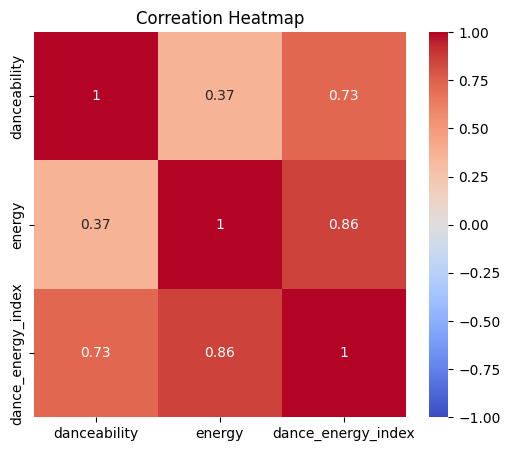

In [16]:
#pearson correlation
import seaborn as sns
import matplotlib.pyplot as plt

features = ['danceability','energy','dance_energy_index']
corr = df[features].corr(method='pearson')
print(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr,annot=True,cmap='coolwarm',vmin=-1,vmax=1)
plt.title('Correation Heatmap')
plt.show()

#dance_energy_index feature shows a strong positive correlation with both its constituent parts: 
#0.73 with danceability and 0.86 with energy

            loudness  popularity
loudness    1.000000    0.317011
popularity  0.317011    1.000000


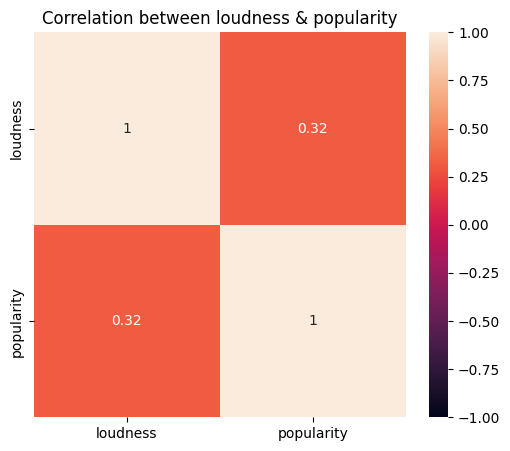

In [17]:
#spearman correlation
features=['loudness','popularity']
corr=df[features].corr(method='spearman')
print(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr,annot=True,vmin=-1,vmax=1)
plt.title('Correlation between loudness & popularity')
plt.show()

#louder tracks have a slight advantage in popularity, 
#but loudness alone explains only a small portion of what makes music successful

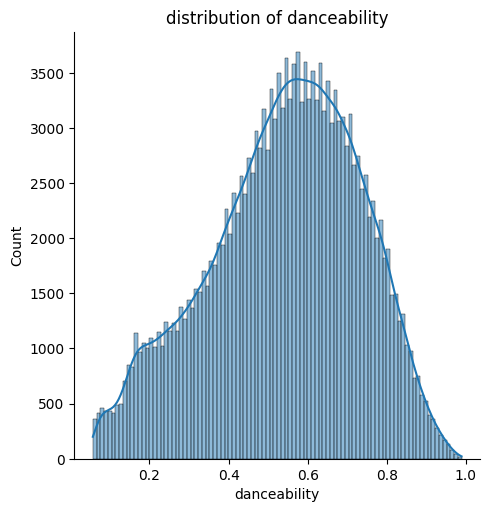

In [18]:
#distribution plot for 'danceability'

sns.displot(data=df,x='danceability',kde=True)
plt.title('distribution of danceability')
plt.show()

#the data follows a roughly normal distribution with a slight left skew
#the peak occurs around 0.6-0.7.

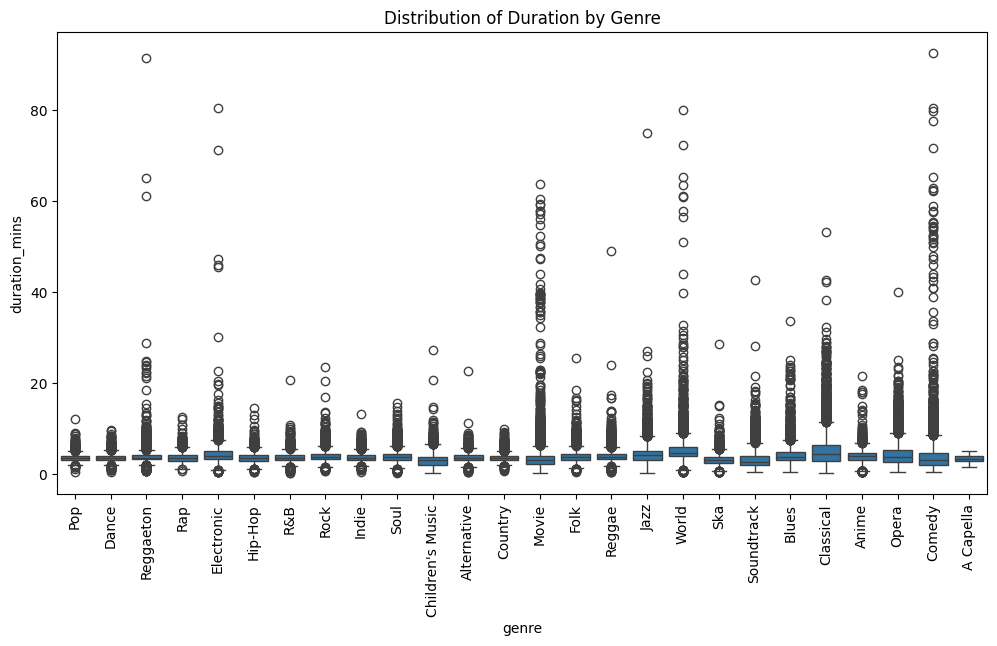

In [19]:
#distribution of 'duration' across different genres

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='genre', y='duration_mins')
plt.xticks(rotation=90)
plt.title('Distribution of Duration by Genre')
plt.show()

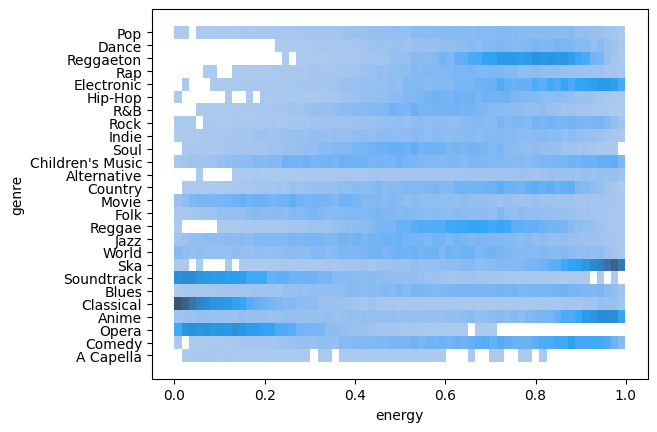

In [20]:
#distribution of 'energy' across different genres

import plotly.express as px

fig = sns.histplot(df,x='energy', y='genre')
plt.show()

#Electronic-based genres (Electronic, Dance) cluster at the high end
#Acoustic/traditional genres (Classical, Jazz, Folk) cluster at the low end
#Popular mainstream genres (Pop, Rock, Hip-Hop) form a middle cluster

#Children's Music shows moderate energy levels, possibly balancing engagement with calmness

Visualization with Seaborn

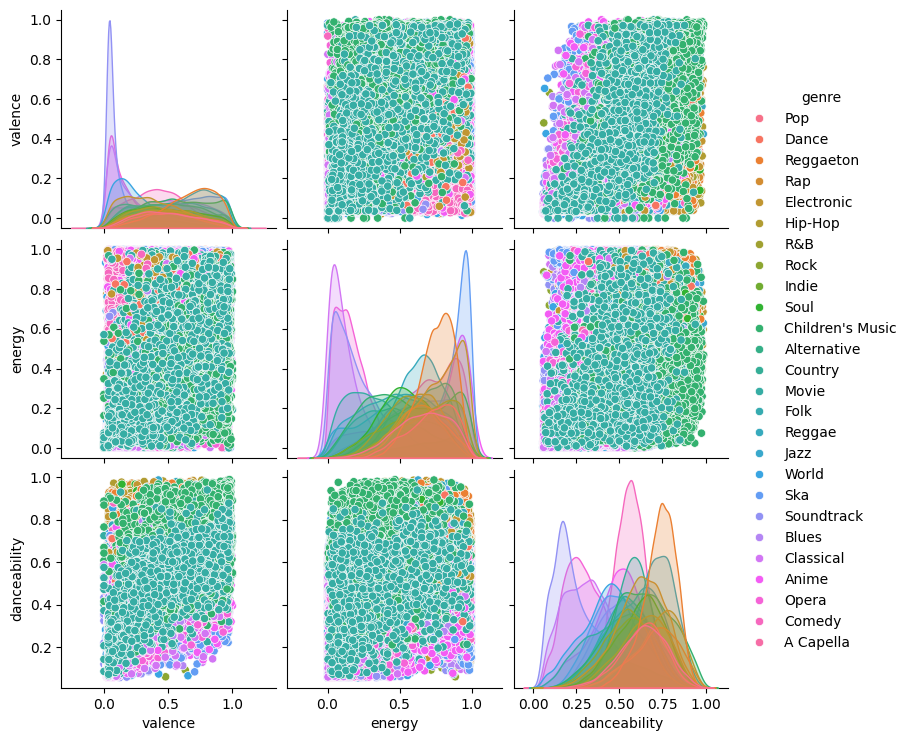

In [21]:
#scatter matrix of audio features colored by 'genre'
#this scatter matrix visualizes the relationships between three audio features:
# energy, danceability, and valence.
# Each point represents a song, colored by its genre.

import  seaborn as sns

features=['valence', 'energy', 'danceability']
sns.pairplot(df,vars=features,hue='genre')
plt.show()

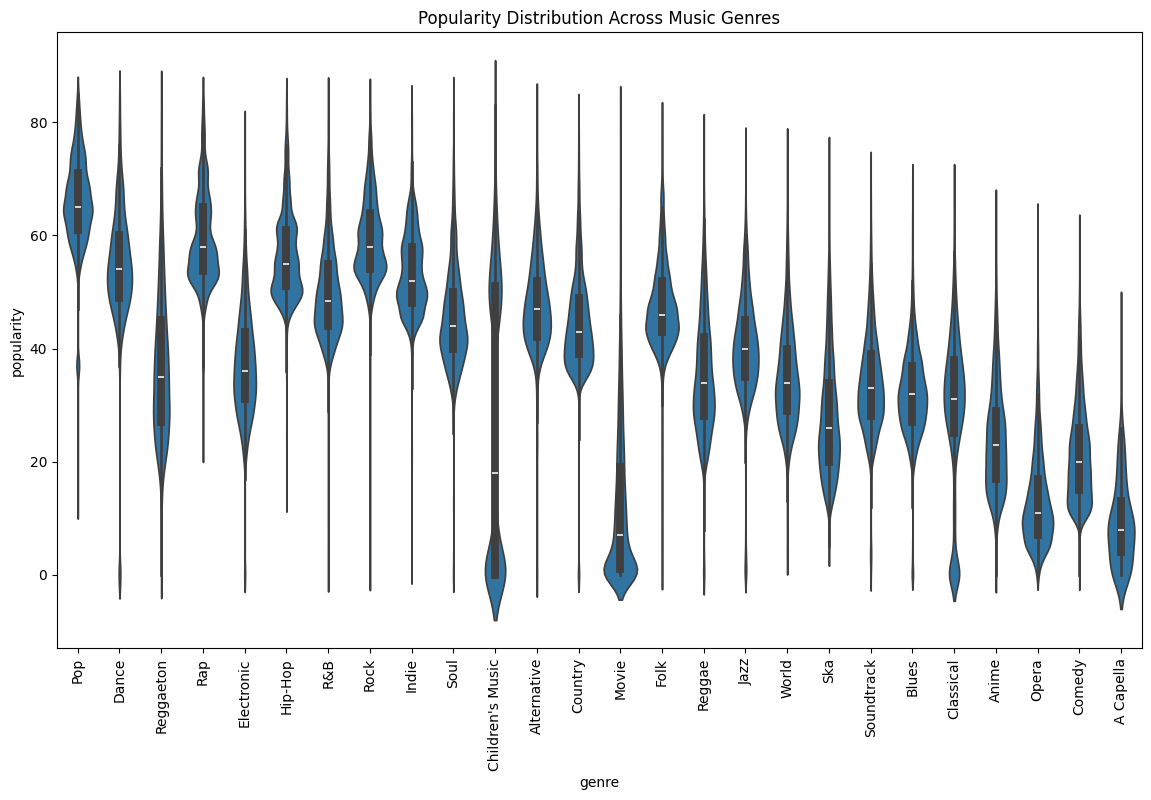

In [22]:
#Violin plot show the distribution of popularity within each 'genre'

plt.figure(figsize=(14, 8))
sns.violinplot(data=df, x='genre', y='popularity')
plt.xticks(rotation=90)
plt.title('Popularity Distribution Across Music Genres')
plt.show()

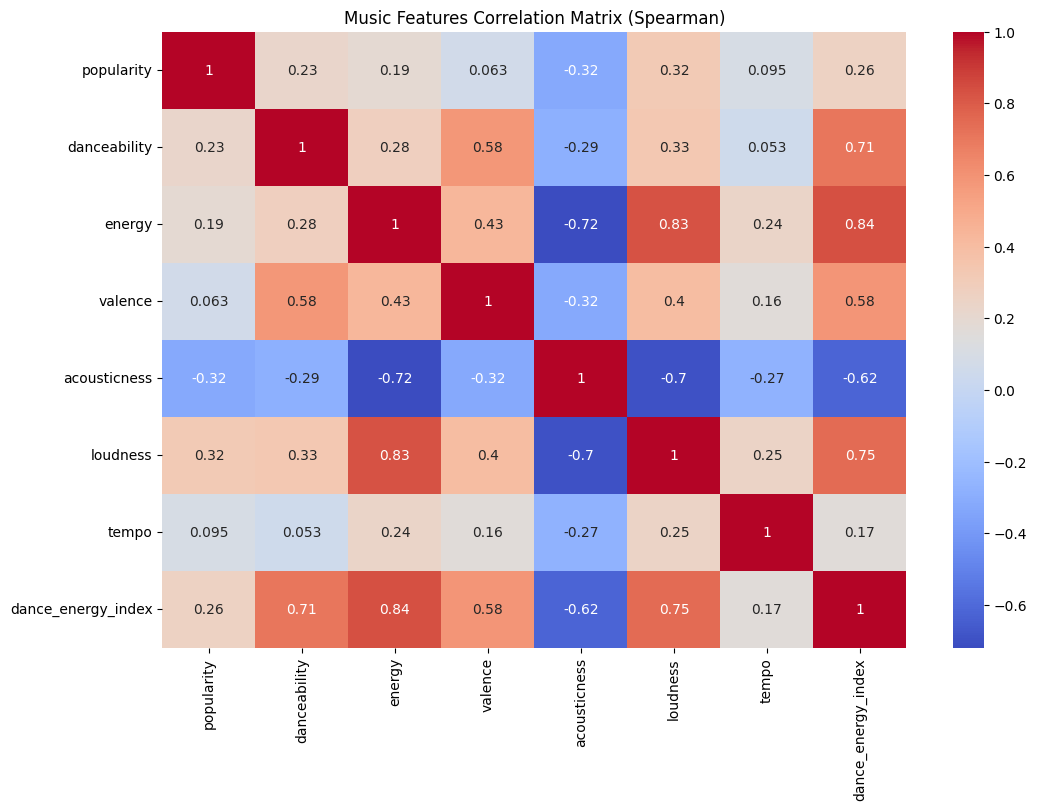

In [23]:
#Music features correlation matrix

numerical_features = ['popularity', 'danceability', 'energy', 'valence', 
                     'acousticness', 'loudness', 'tempo', 'dance_energy_index']
correlation_matrix = df[numerical_features].corr(method='spearman')

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Music Features Correlation Matrix (Spearman)')
plt.show()

#this heatmap reveals how musical characteristics relate to each other. 
#Strong positive correlations (dark red) indicate features that typically increase together, like energy and loudness. 
#Negative correlations (dark blue) show inverse relationships, like acousticness and energy. 

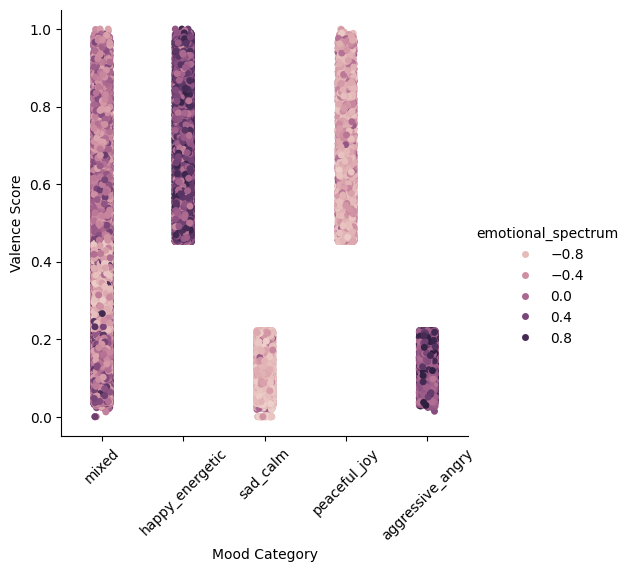

In [24]:
#categorical plot for emotional analysis
g = sns.catplot(data=df, x='mood_category', y='valence', 
                hue='emotional_spectrum')
g.set_axis_labels('Mood Category', 'Valence Score')
g.set_titles('Valence Distribution by Mood and Emotional Spectrum')
plt.xticks(rotation=45)
plt.show()

#this categorical plot examines how valence(musical positivity) 
#distributes across created mood categories and emotional spectrum.

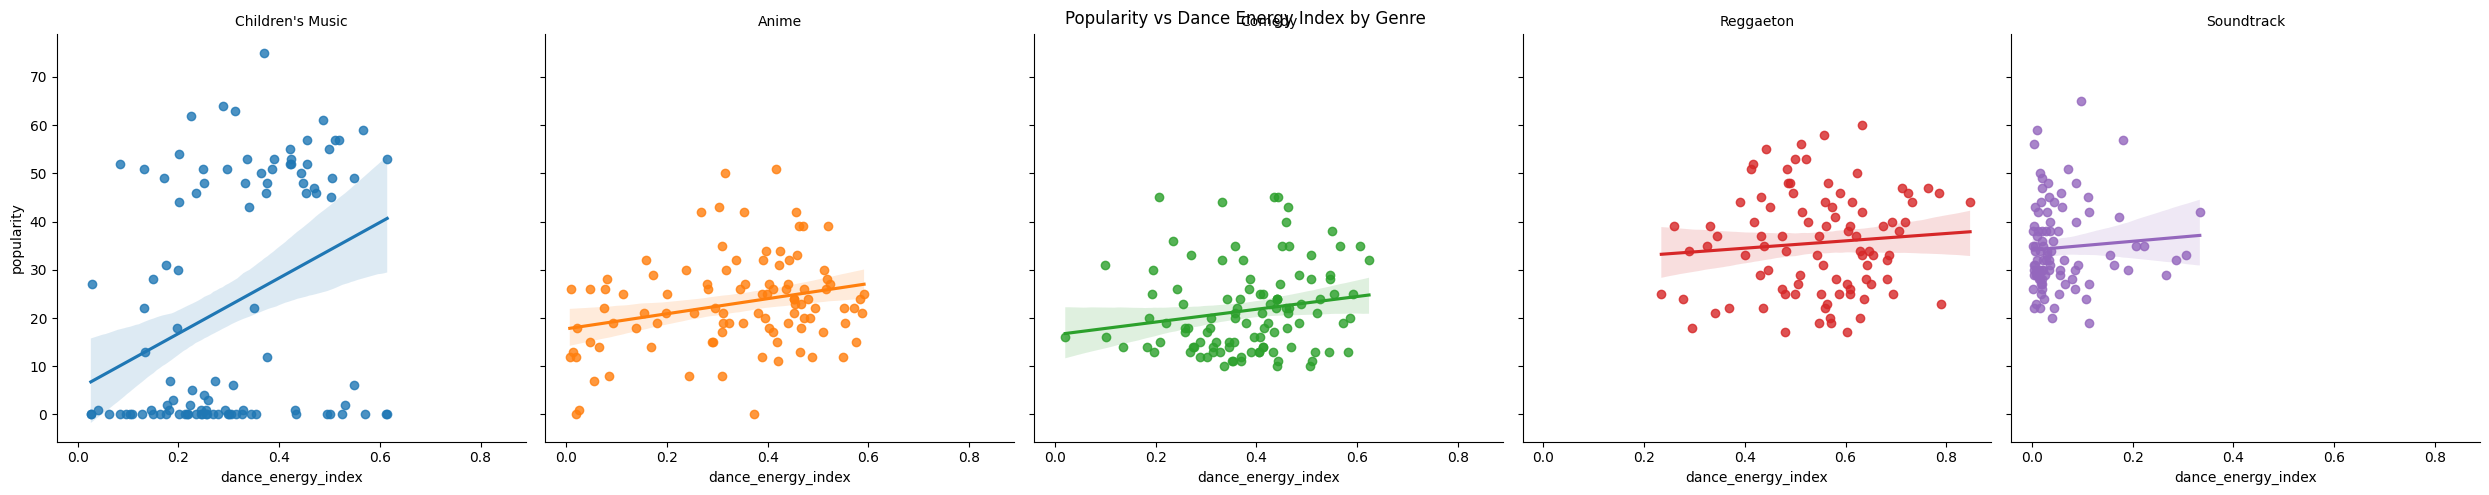

In [25]:
# Analyze how dance energy relates to popularity across genres
top_5_genres = df['genre'].value_counts().head(5).index
df_sample = df[df['genre'].isin(top_5_genres)].sample(500)

g = sns.lmplot(data=df_sample, x='dance_energy_index', y='popularity',
               hue='genre', col='genre')
g.set_titles('{col_name}')
plt.suptitle('Popularity vs Dance Energy Index by Genre')
plt.show()

#these regression plots show how dance_energy_index predicts popularity across different genres. 

Interactive Visualizations with Plotly

In [26]:
#Bar chart comparing average popularity across mood categories

import plotly.express as px

mood_stats = df.groupby('mood_category').agg({
    'popularity': 'mean',
    'track_name': 'count'
}).reset_index()
mood_stats.columns = ['mood_category', 'avg_popularity', 'song_count']

fig = px.bar(mood_stats, x='mood_category', y='avg_popularity')
fig.show()

In [27]:
#create a violin plot with box plots inside to visualize tempo distribution across genres
#Violin plot shows the probability density of tempo values for each genre
#Box plot inside shows quartiles, median, and potential outliers

fig = px.violin(df, x='genre', y='tempo', title='Tempo for each genre',box=True)
fig.update_xaxes(tickangle=45)
fig.show()

In [28]:
#interactive scatter plot of danceability vs. energy
#Sample 500 random tracks to avoid overplotting and improve performance
fig = px.scatter(df.sample(500),  #random sample for clearer visualization
                 x='danceability',        
                 y='energy',              
                 color='genre',           #color points by genre for categorical distinction
                 hover_data=['track_name'],  #shows track name on hover for identification
                 title='Danceability vs. Energy: Track Analysis', 
                 size='popularity')       #point size represents track popularity
fig.show()

In [ ]:
#interactive pie chart showing distribution of tracks across mood categories

mood_counts = df['mood_category'].value_counts()

fig = px.pie(mood_counts, values=mood_counts.values, names=mood_counts.index)
fig.show()